# Import Models 

In [1]:
import os
import subprocess
import pandas as pd
import numpy as np
import optuna
from optuna.samplers import NSGAIIISampler
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

C:\Users\hp\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Build the python script for simulation running 

In [2]:
ECLRUN_EXE = r"C:\ecl\macros\eclrun.exe"

BASE_DIR = r"C:\Users\hp\Desktop\Eclipse 100"  # we did the simulation for TPE & NSGA on the same DATA file 

DATA_FILE_NAME = "Egg_Model_ECL.DATA"
SCHEDULE_FILE_NAME = "SCHEDULE_NEW.INC"
RSM_PATH = r"C:\Users\hp\Desktop\Eclipse 100\EGG_MODEL_ECL.RSM"

In [3]:
def modify_files(params):
#____________________________________________________________
    sched_path = os.path.join(BASE_DIR, SCHEDULE_FILE_NAME)

    inj_map = {
        "INJECT1": params["inj_rate1"],
        "INJECT2": params["inj_rate2"],
        "INJECT3": params["inj_rate3"],
        "INJECT4": params["inj_rate4"],
        "INJECT5": params["inj_rate5"],
        "INJECT6": params["inj_rate6"],
        "INJECT7": params["inj_rate7"],
        "INJECT8": params["inj_rate8"],
    }

    with open(sched_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        stripped = line.strip()

        for well, rate in inj_map.items():
            if stripped.startswith(f"'{well}'") and "'RATE'" in stripped:
                parts = stripped.split()

                # Find RATE keyword index safely
                rate_idx = parts.index("'RATE'") + 1
                parts[rate_idx] = str(int(rate))

                line = " ".join(parts) + "\n"

        new_lines.append(line)

    with open(sched_path, "w") as f:
        f.writelines(new_lines)

#_____________________________________________________________
    data_path = os.path.join(BASE_DIR, DATA_FILE_NAME)

    prod_map = {
        "PROD1": params["BHP1"],
        "PROD2": params["BHP2"],
        "PROD3": params["BHP3"],
        "PROD4": params["BHP4"],
    }
    with open(data_path, "r") as f:
        lines = f.readlines()

    new_lines = []
    for line in lines:
        stripped = line.strip()

        for well, bhp in prod_map.items():
            if stripped.startswith(f"'{well}'") and "'BHP'" in stripped:
                parts = stripped.split()
                parts[-1] = f"{int(bhp)}/"
                line = " ".join(parts) + "\n"

        new_lines.append(line)

    with open(data_path, "w") as f:
        f.writelines(new_lines)

In [4]:
def run_eclipse():
    cmd = [
        ECLRUN_EXE,
        "eclipse",
        DATA_FILE_NAME
    ]
    subprocess.run(cmd, cwd=BASE_DIR, check=True)
    
def extract_FOPT_FWPT_from_RSM(rsm_path):

    with open(rsm_path, "r") as f:
        lines = f.readlines()

    inside_summary = False
    fopt_idx = fwpt_idx = None

    for line in lines:

        if "SUMMARY OF RUN" in line:
            inside_summary = True
            fopt_idx = fwpt_idx = None
            continue

        if not inside_summary:
            continue

        tokens = line.split()
        if not tokens:
            continue

        # Detect column headers
        if fopt_idx is None and "FOPT" in tokens and "FWPT" in tokens:
            fopt_idx = tokens.index("FOPT")
            fwpt_idx = tokens.index("FWPT")
            continue

        if fopt_idx is None:
            continue

        # ✅ Only data rows have numeric TIME
        if not tokens[0][0].isdigit():
            continue
        if float(tokens[0]) == 3600.0:
            return float(tokens[fopt_idx]), float(tokens[fwpt_idx])

# Define the TPE objective function

In [5]:
def objective(trial):

    # ---------------------------------------------
    # 1. TPE parameter suggestions (with BHP gap constraint)
    # ---------------------------------------------
    BHP_LOW, BHP_HIGH = 150, 390
    MAX_BHP_GAP = 50          # <-- tune this: max allowed spread between wells (bar)
    half_gap = MAX_BHP_GAP // 2

    # Center pressure for the group of producers, kept far enough from the
    # bounds so that center +/- half_gap always stays inside [150, 390]
    center = trial.suggest_int("BHP_center", BHP_LOW + half_gap, BHP_HIGH - half_gap)

    BHP1 = center + trial.suggest_int("BHP1_offset", -half_gap, half_gap)
    BHP2 = center + trial.suggest_int("BHP2_offset", -half_gap, half_gap)
    BHP3 = center + trial.suggest_int("BHP3_offset", -half_gap, half_gap)
    BHP4 = center + trial.suggest_int("BHP4_offset", -half_gap, half_gap)

    params = {
        "BHP1": BHP1,
        "BHP2": BHP2,
        "BHP3": BHP3,
        "BHP4": BHP4,
        "inj_rate1": trial.suggest_int("inj_rate1", 50, 100),
        "inj_rate2": trial.suggest_int("inj_rate2", 50, 100),
        "inj_rate3": trial.suggest_int("inj_rate3", 50, 100),
        "inj_rate4": trial.suggest_int("inj_rate4", 50, 100),
        "inj_rate5": trial.suggest_int("inj_rate5", 50, 100),
        "inj_rate6": trial.suggest_int("inj_rate6", 50, 100),
        "inj_rate7": trial.suggest_int("inj_rate7", 50, 100),
        "inj_rate8": trial.suggest_int("inj_rate8", 50, 100),
    }

    # ---------------------------------------------
    # 2. Modify Eclipse input files
    # ---------------------------------------------
    modify_files(params)

    # ---------------------------------------------
    # 3. Run Eclipse
    # ---------------------------------------------
    try:
        run_eclipse()
    except subprocess.CalledProcessError:
        return -1e12, 1e12

    # ---------------------------------------------
    # 4. Read results
    # ---------------------------------------------
    fopt, fwpt = extract_FOPT_FWPT_from_RSM(RSM_PATH)

    return fopt, fwpt

# TPE optimization running

In [7]:
sampler1 = optuna.samplers.TPESampler(
    n_startup_trials=42,
    multivariate=False,
    seed=42)

study1 = optuna.create_study(
    directions=["maximize", "minimize"],
    sampler=sampler1,
    study_name="ECLIPSE_SUM_DELTA_FOPT_FWPT"
)

study1.optimize(objective, n_trials=100, show_progress_bar=False)

[I 2026-08-05 21:54:45,793] A new study created in memory with name: ECLIPSE_SUM_DELTA_FOPT_FWPT
[I 2026-08-05 21:55:40,623] Trial 0 finished with values: [497218.4, 1703741.0] and parameters: {'BHP_center': 246, 'BHP1_offset': 23, 'BHP2_offset': 12, 'BHP3_offset': 5, 'BHP4_offset': -18, 'inj_rate1': 57, 'inj_rate2': 52, 'inj_rate3': 94, 'inj_rate4': 80, 'inj_rate5': 86, 'inj_rate6': 51, 'inj_rate7': 99, 'inj_rate8': 92}. 
[I 2026-08-05 21:56:51,703] Trial 1 finished with values: [497275.2, 1552966.0] and parameters: {'BHP_center': 215, 'BHP1_offset': -16, 'BHP2_offset': -16, 'BHP3_offset': -10, 'BHP4_offset': 1, 'inj_rate1': 72, 'inj_rate2': 64, 'inj_rate3': 81, 'inj_rate4': 57, 'inj_rate5': 64, 'inj_rate6': 68, 'inj_rate7': 73, 'inj_rate8': 90}. 
[I 2026-08-05 21:57:38,410] Trial 2 finished with values: [502131.8, 1666792.0] and parameters: {'BHP_center': 213, 'BHP1_offset': 1, 'BHP2_offset': 5, 'BHP3_offset': -23, 'BHP4_offset': 5, 'inj_rate1': 58, 'inj_rate2': 53, 'inj_rate3': 98, 

# Optimization results

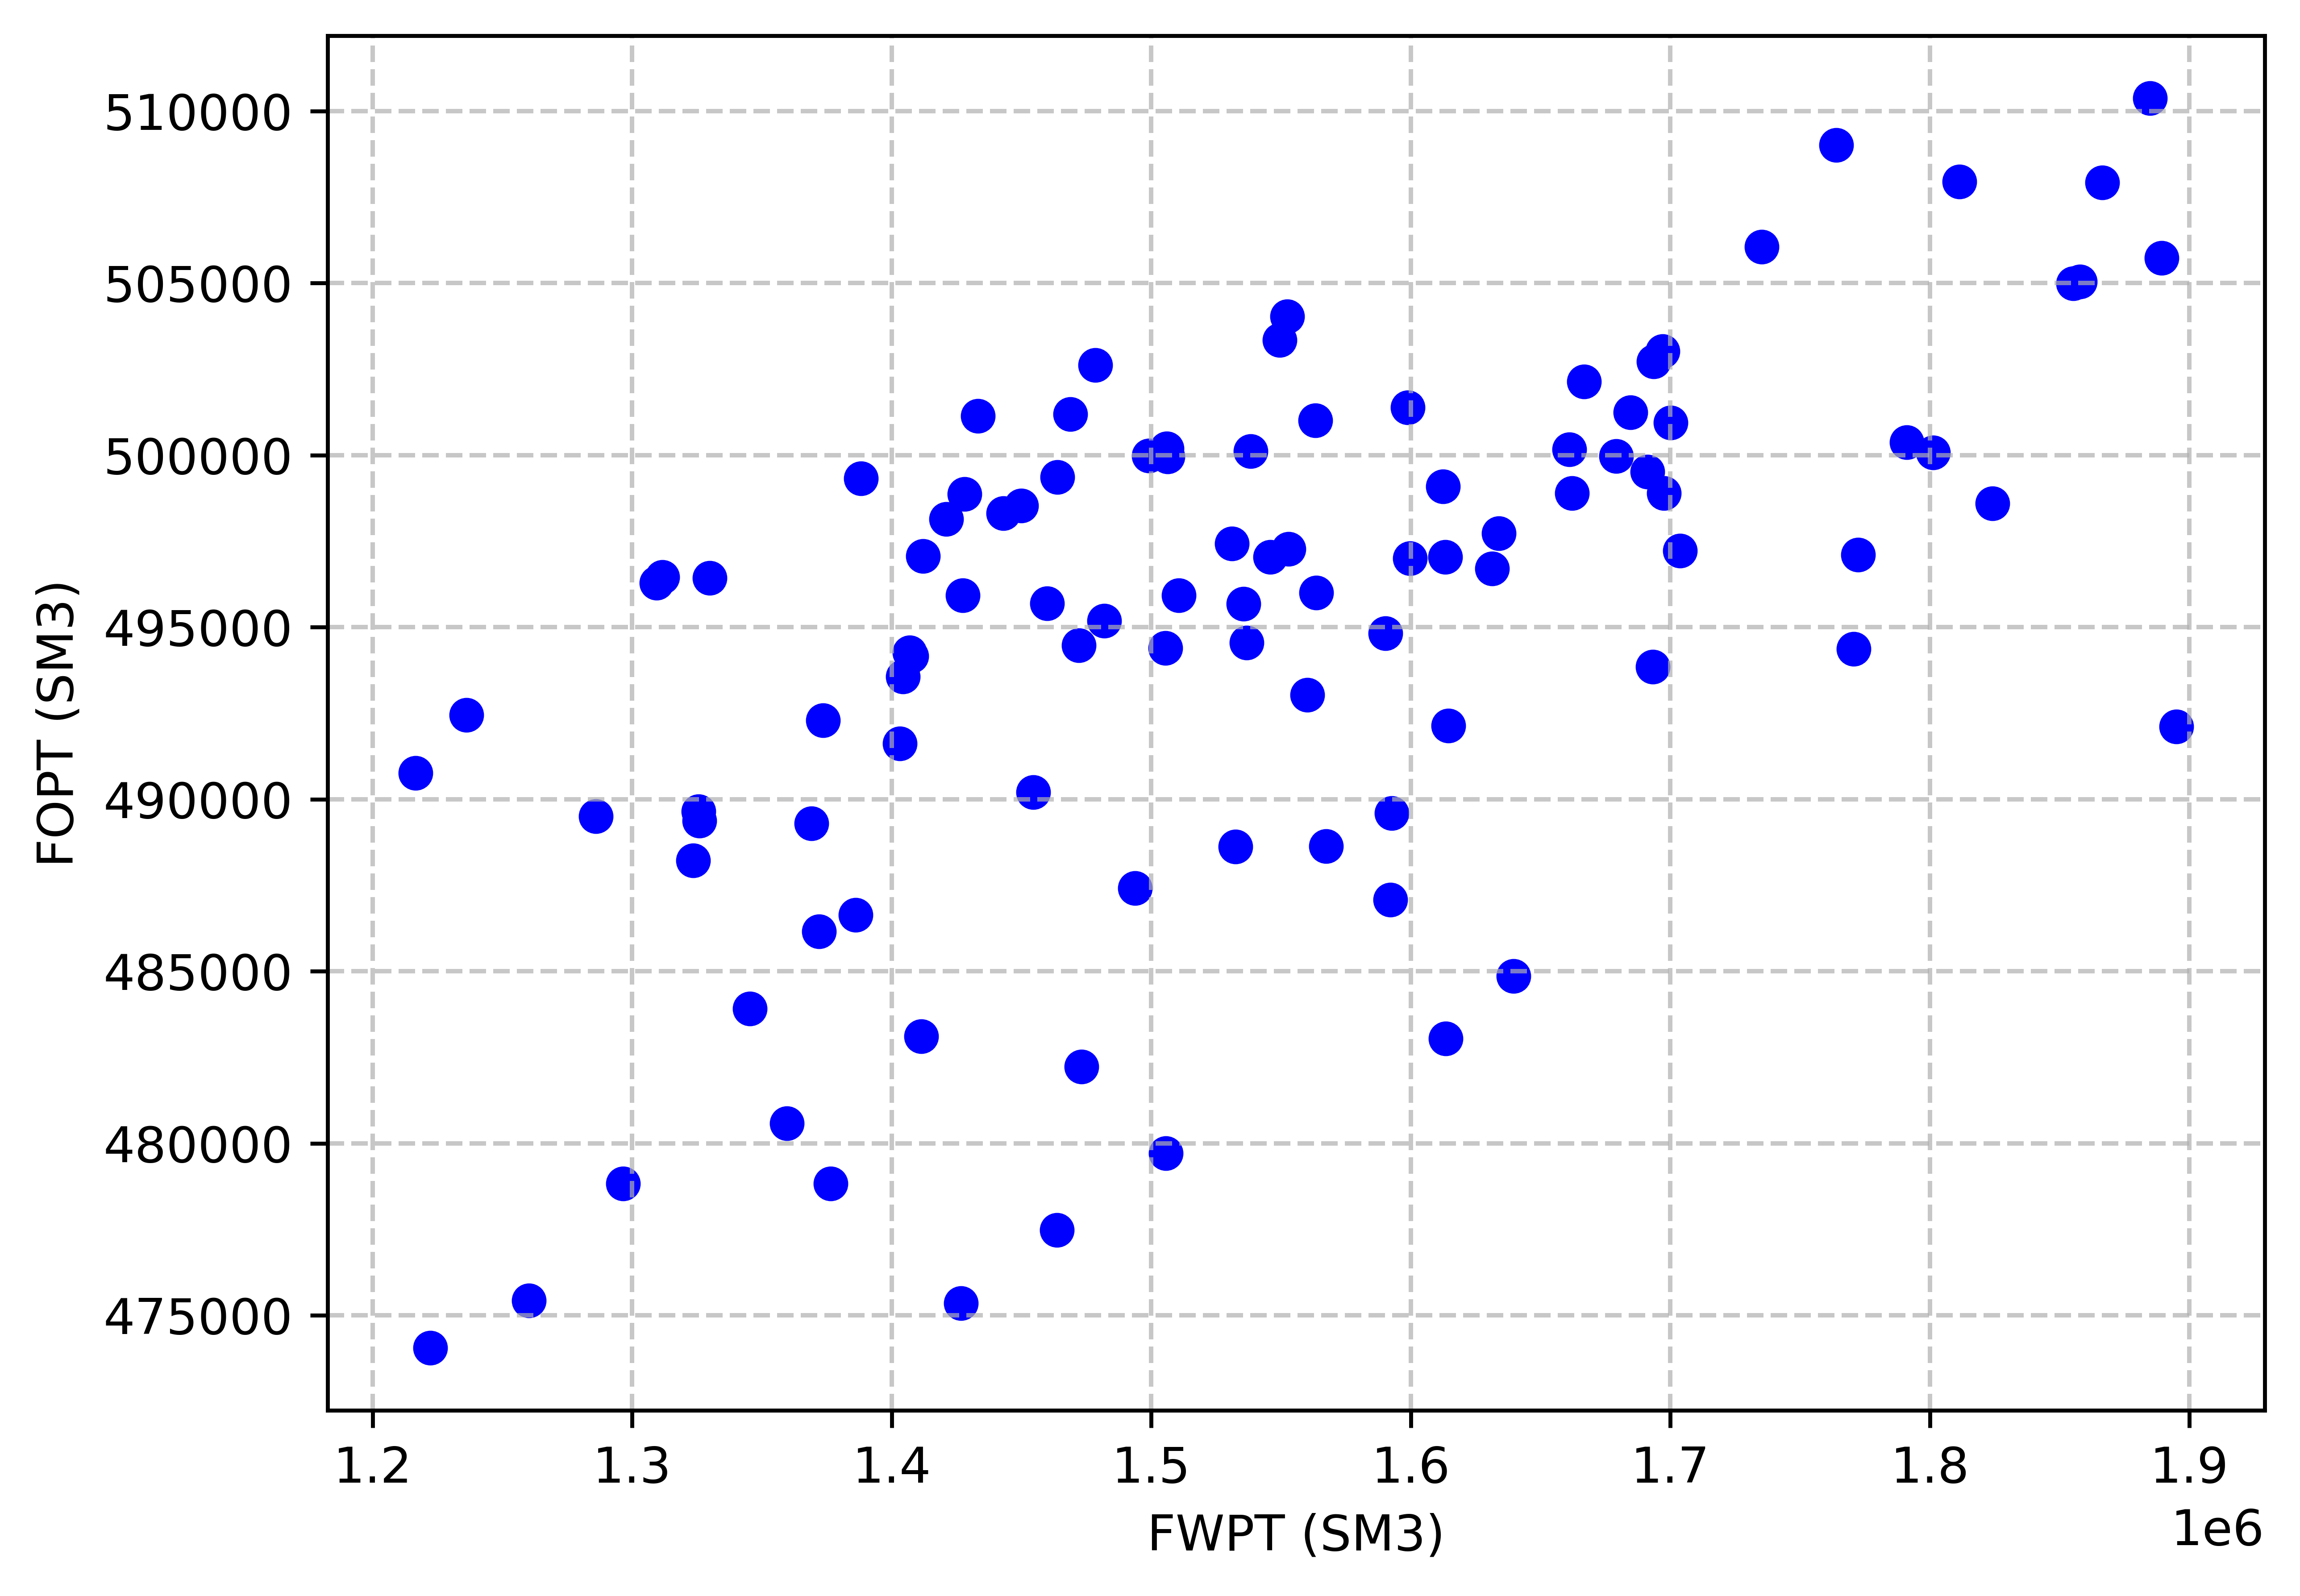

In [8]:
pareto_trials = study1.best_trials
fopts = [t.values[0] for t in study1.trials if t.values is not None]
fwpts = [t.values[1] for t in study1.trials if t.values is not None]

plt.figure(figsize=(7,5),dpi=800)
plt.scatter(fwpts, fopts, c='blue')
plt.xlabel("FWPT (SM3)")
plt.ylabel("FOPT (SM3)")
plt.grid(True, which="major", linestyle="--", linewidth=0.9, alpha=0.7)
plt.grid(True, which="minor", linestyle="--", linewidth=0.5, alpha=0.4)
plt.show()

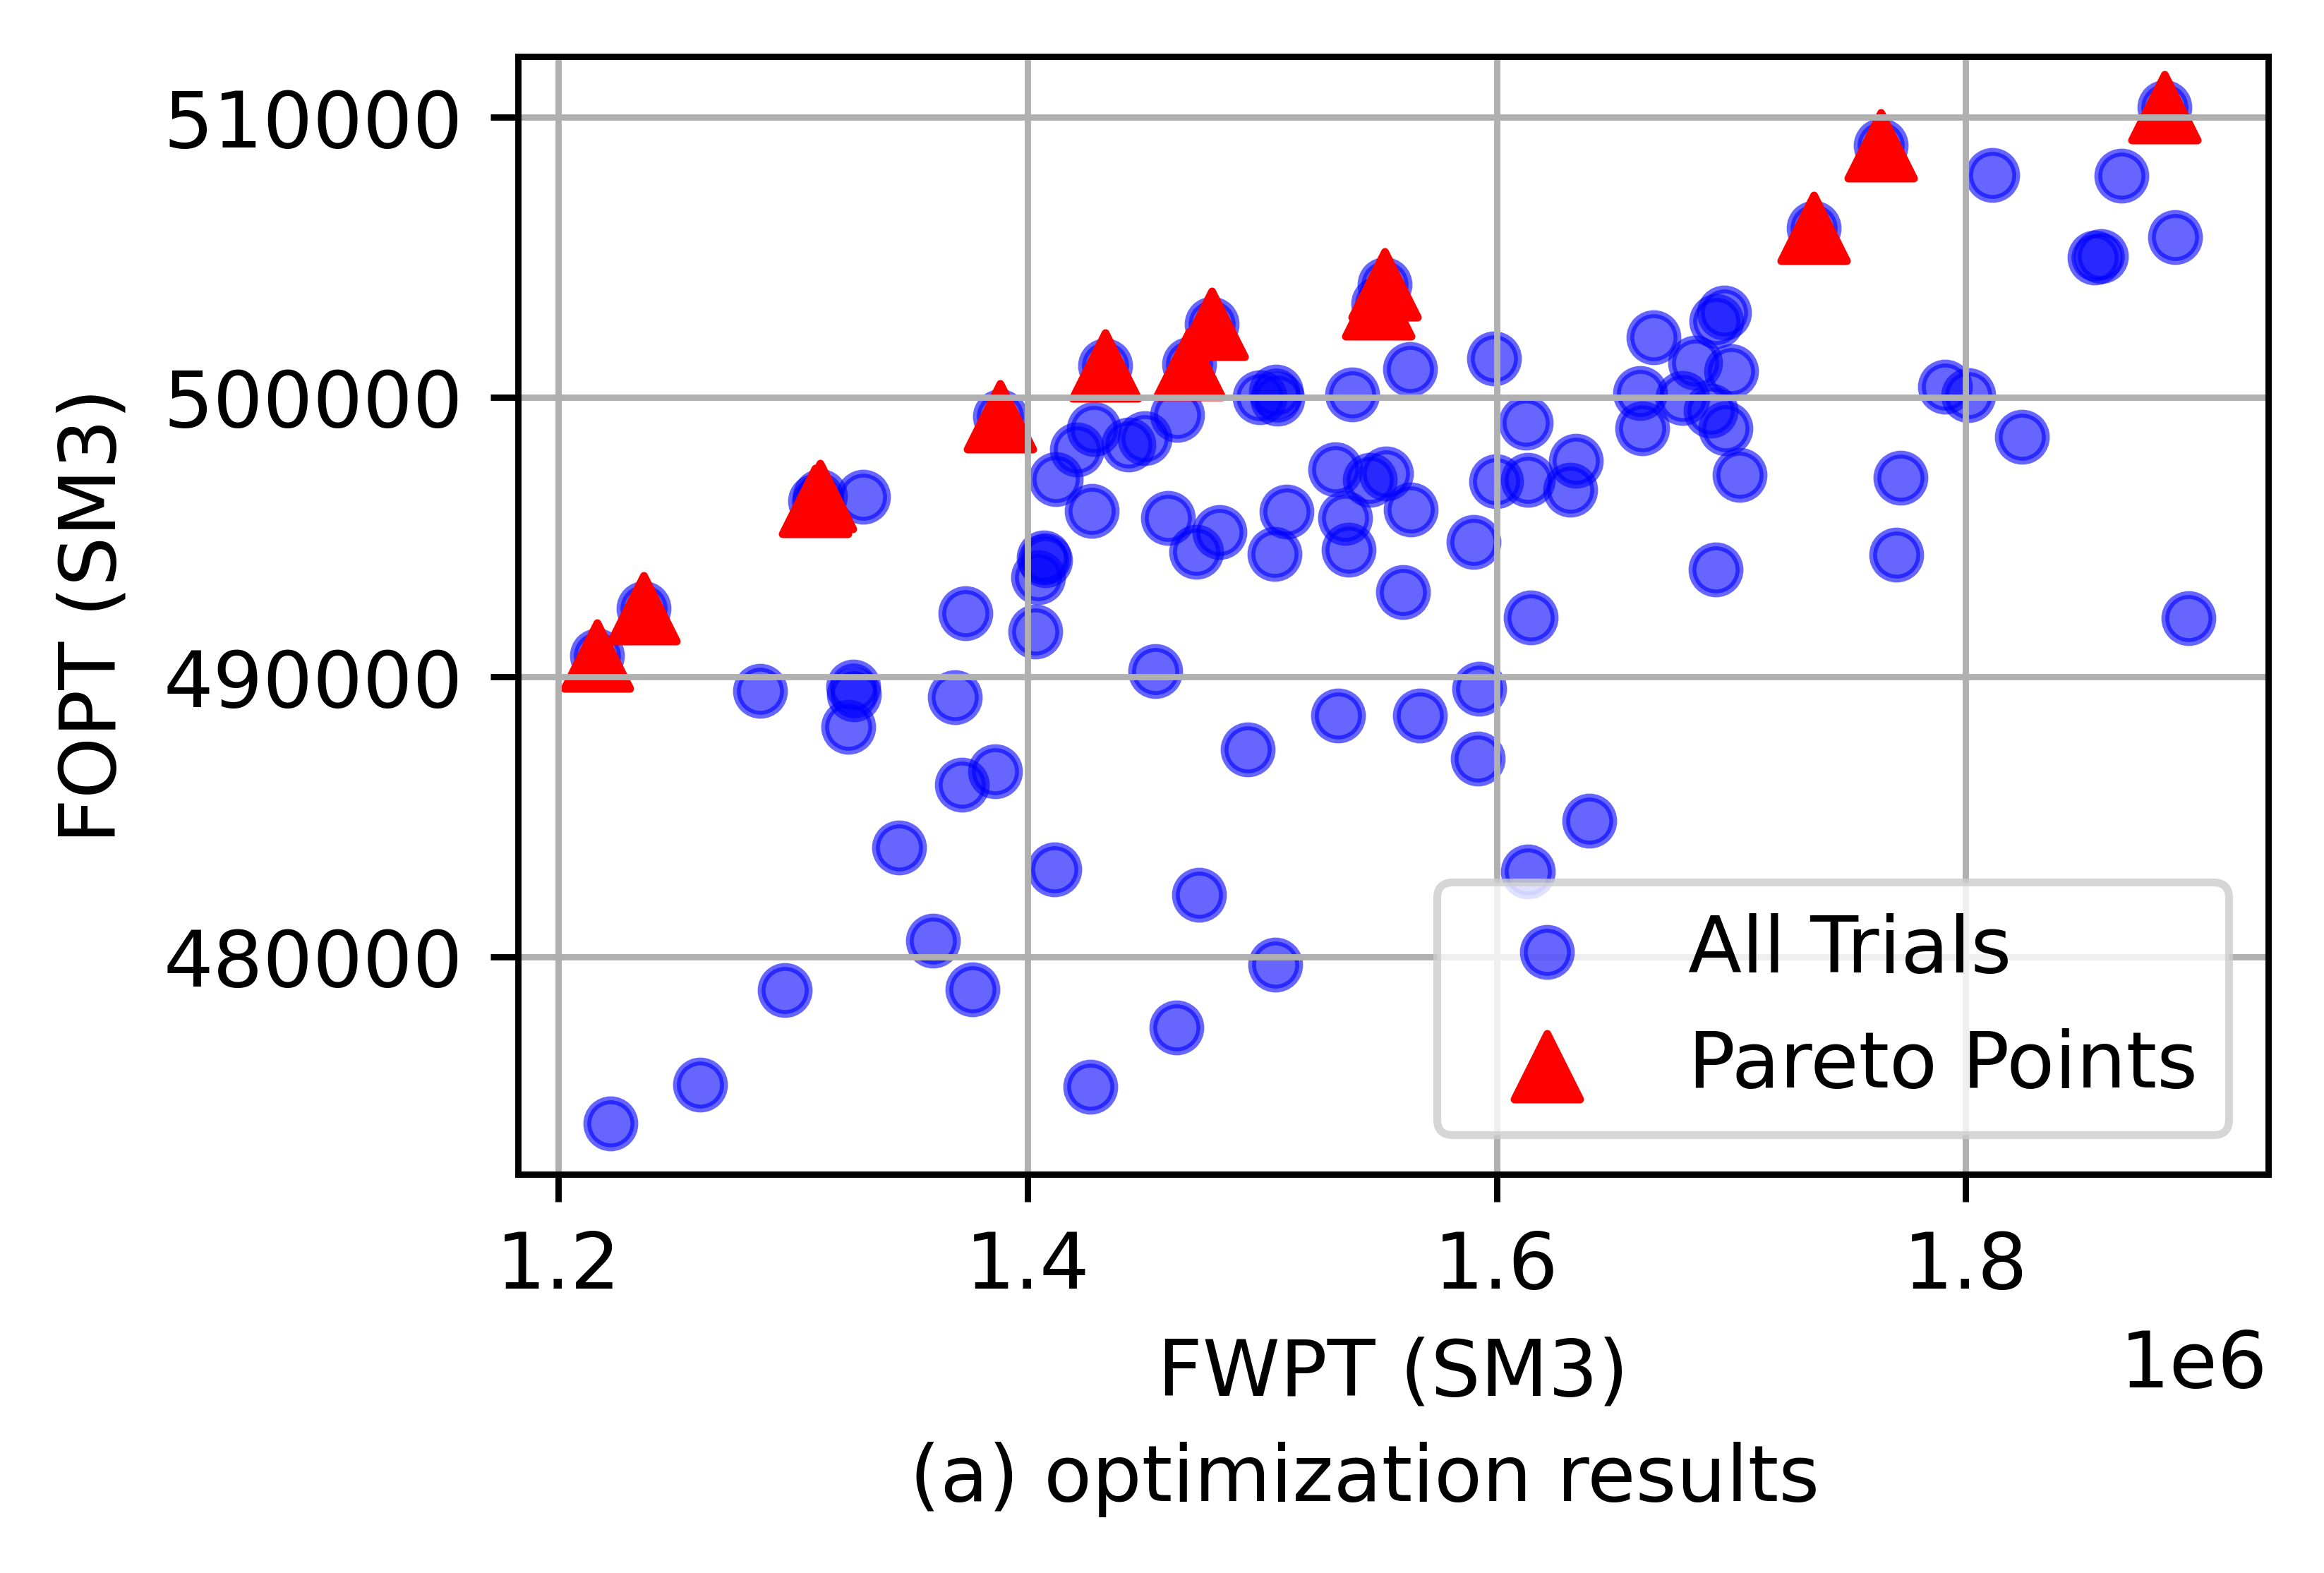

In [13]:
fopts = [t.values[0] for t in study1.trials if t.values is not None]
fwpts = [t.values[1] for t in study1.trials if t.values is not None]

# --- Pareto optimal trials ---
pareto_trials = study1.best_trials
pareto_fopts = [t.values[0] for t in pareto_trials]
pareto_fwpts = [t.values[1] for t in pareto_trials]

# --- Sort Pareto points by FWPT (minimization axis) ---
pareto_points = sorted(zip(pareto_fwpts, pareto_fopts))
pareto_fwpts_sorted, pareto_fopts_sorted = zip(*pareto_points)

fig, ax = plt.subplots(figsize=(4, 3), dpi=800)

# All solutions
ax.scatter(fwpts, fopts, color='blue', alpha=0.6, label='All Trials')

# Pareto points
ax.scatter(
    pareto_fwpts_sorted,
    pareto_fopts_sorted,
    color='red',
    marker='^',
    s=70,
    label='Pareto Points'
)

ax.set_xlabel("FWPT (SM3)")
ax.set_ylabel("FOPT (SM3)")
ax.legend()
ax.grid(True)

# Leave space at the bottom
plt.subplots_adjust(bottom=0.22)

# Add panel label below the figure
fig.text(
    0.5, 0.04,
    "(a) optimization results",
    ha="center",
    va="center",
    fontsize=10
)

plt.show()

In [11]:
print("\nPareto Front Table\n")
print("Trial\tFOPT\tFWPT")

for trial in pareto_trials:
    print(f"{trial.number}\t{trial.values[0]:.2f}\t{trial.values[1]:.2f}")


Pareto Front Table

Trial	FOPT	FWPT
16	506053.40	1735235.00
17	510374.10	1884794.00
35	509009.60	1763945.00
42	504028.10	1552398.00
43	503343.80	1549484.00
50	492443.00	1236169.00
78	490754.90	1216557.00
82	501184.90	1468905.00
85	496454.80	1311605.00
86	501139.00	1433184.00
89	502617.40	1478530.00
90	499315.50	1388191.00
94	496279.60	1309382.00


In [14]:
print("\nPareto Optimal Solutions:\n")

for i, trial in enumerate(pareto_trials):
    print(f"Solution {i+1}")
    print("Trial number:", trial.number)
    print("FOPT (maximize):", trial.values[0])
    print("FWPT (minimize):", trial.values[1])
    print("Parameters:", trial.params)
    print("-" * 40)


Pareto Optimal Solutions:

Solution 1
Trial number: 16
FOPT (maximize): 506053.4
FWPT (minimize): 1735235.0
Parameters: {'BHP_center': 175, 'BHP1_offset': -17, 'BHP2_offset': 2, 'BHP3_offset': 10, 'BHP4_offset': 8, 'inj_rate1': 61, 'inj_rate2': 86, 'inj_rate3': 62, 'inj_rate4': 66, 'inj_rate5': 88, 'inj_rate6': 83, 'inj_rate7': 93, 'inj_rate8': 83}
----------------------------------------
Solution 2
Trial number: 17
FOPT (maximize): 510374.1
FWPT (minimize): 1884794.0
Parameters: {'BHP_center': 283, 'BHP1_offset': -21, 'BHP2_offset': -7, 'BHP3_offset': -12, 'BHP4_offset': -13, 'inj_rate1': 99, 'inj_rate2': 70, 'inj_rate3': 95, 'inj_rate4': 82, 'inj_rate5': 90, 'inj_rate6': 75, 'inj_rate7': 79, 'inj_rate8': 75}
----------------------------------------
Solution 3
Trial number: 35
FOPT (maximize): 509009.6
FWPT (minimize): 1763945.0
Parameters: {'BHP_center': 269, 'BHP1_offset': -25, 'BHP2_offset': -2, 'BHP3_offset': -23, 'BHP4_offset': -19, 'inj_rate1': 55, 'inj_rate2': 83, 'inj_rate3':

# Best optimal with contraint

In [31]:
FWPT_max = 6200000  # constraint on water production

# Extract Pareto values
fopt = np.array([t.values[0] for t in pareto_trials])
fwpt = np.array([t.values[1] for t in pareto_trials])

# ===============================
# Apply constraint (FWPT <= limit)
# ===============================
valid_indices = [i for i, fw in enumerate(fwpt) if fw <= FWPT_max]

if valid_indices:

    # Select best FOPT among valid ones
    best_idx = max(valid_indices, key=lambda i: fopt[i])
    best_trial_constraint = pareto_trials[best_idx]

    # --- Extract values ---
    best_fopt = best_trial_constraint.values[0]
    best_fwpt = best_trial_constraint.values[1]
    params = best_trial_constraint.params

    # --- Separate BHP and Injection rates ---
    bhp_params = {k: v for k, v in params.items() if "BHP" in k}
    inj_params = {k: v for k, v in params.items() if "inj" in k.lower()}

    # --- Print results ---
    print("========== CONSTRAINED OPTIMAL SOLUTION ==========")
    print(f"Trial Number : {best_trial_constraint.number}")
    print(f"FOPT         : {best_fopt}")
    print(f"FWPT         : {best_fwpt}")

    print("\n--- BHP Parameters ---")
    for k, v in bhp_params.items():
        print(f"{k}: {v}")

    print("\n--- Injection Rate Parameters ---")
    for k, v in inj_params.items():
        print(f"{k}: {v}")

else:
    print("No Pareto solution satisfies the FWPT constraint.")

========== CONSTRAINED OPTIMAL SOLUTION ==========
Trial Number : 132
FOPT         : 556053.1
FWPT         : 5951074.0

--- BHP Parameters ---
BHP_center: 182
BHP1_offset: 18
BHP2_offset: 8
BHP3_offset: 0
BHP4_offset: -21

--- Injection Rate Parameters ---
inj_rate1: 393
inj_rate2: 206
inj_rate3: 389
inj_rate4: 75
inj_rate5: 277
inj_rate6: 217
inj_rate7: 87
inj_rate8: 163
